In [1]:
import torch
import os
from torch.utils.data import Dataset, DataLoader, random_split, Subset, WeightedRandomSampler
from torchvision import transforms
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle
from sklearn.metrics import matthews_corrcoef, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import re
from MambaFRZ import initialize_mamba2_predictor
from CompressedDatasetMambaFRZ import CompressedFreezeDataset
from collections import defaultdict

/home/idies/workspace/Storage/ktuzinows1/persistent/pytorch_env/PleaseWork/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def generate_formatted_data(file_list, dataset_file, folder_location, subfolder, total_count):
  counter = 0

  # Pattern for extracting Layer Name, Epoch, and Seed
  pattern = r"layer_([^_]*)_epoch_(\d*)_(\d*)"

  for filename in file_list:
    if filename.endswith('.pkl'):
      counter += 1
      print(filename, f"{counter}/{total_count}")
      with open(os.path.join(folder_location, filename), "rb") as f:
        tensor_data = pickle.load(f)
        freeze_input = tensor_data[0]

        for index, weight in enumerate(tensor_data):
          if index == 0:
            continue
          freeze_input = torch.cat((freeze_input, weight), 0)

        match_for_info = re.match(pattern, filename)
        if match_for_info:
          layer_name = match_for_info.group(1)
          epoch = match_for_info.group(2)
          seed = match_for_info.group(3)
          output_response = (freeze_input, layer_name, epoch, seed)
        else:
          raise ValueError(f"No match within {filename}, does not match and hence fails")

        dataset_file['data'].append(output_response)

        if subfolder == 'frz':
          dataset_file['labels'].append(1)
        else:
          dataset_file['labels'].append(0)

In [3]:
def generate_compressed_dataset(root_dir, total_count):
  compressed_dataset_file = {
    'data': [],
    'labels': []
  }
  
  for subfolder in ['frz', 'nofrz']:
    pickle_folder_location = os.path.join(root_dir, subfolder)
    file_list = os.listdir(pickle_folder_location)
    generate_formatted_data(file_list, compressed_dataset_file, pickle_folder_location, subfolder, total_count)
  with open(f"{root_dir}/compressed_dataset_mambafrz.pkl", "wb") as f:
    pickle.dump(compressed_dataset_file, f)

In [25]:
def main(args):
  root_dir = f"{args.name_of_experiment}/context_window_{args.context_window_size}"
  total_count = args.number_of_samples
  counter = 0
  name_of_experiment = args.name_of_experiment
  window_size = args.context_window_size
  if args.generate_training_data:
      generate_compressed_dataset(root_dir, total_count)
    
  train_dataset = CompressedFreezeDataset(f"{root_dir}/compressed_dataset_mambafrz.pkl")
  all_indices = list(range(len(train_dataset)))
    
  seed_to_indices = defaultdict(list)
  for idx in range(len(train_dataset)):
    _, _, _, seed = train_dataset[idx][0]
    seed_to_indices[seed].append(idx)

  print("The seeds in the dataset: ", seed_to_indices.keys())
  print("The number of entries per seed: ", [len(seed_indices) for seed_indices in seed_to_indices.values()])

  # REPRODUCIBILITY WITH RANDOM SEED
  random.seed(1234)
  chosen_seed = random.choice(list(seed_to_indices.keys())) # or e.g. '42'
  torch.manual_seed(1234)
  print(f"The chosen seed: {chosen_seed}")
  val_indices = seed_to_indices[chosen_seed]

  train_indices = [idx for seed, indices in seed_to_indices.items() if seed != chosen_seed for idx in indices]
    
  train_subset = Subset(train_dataset, train_indices)
  val_subset = Subset(train_dataset, val_indices)
    
  batch_size = 8
  num_workers = min(8, os.cpu_count() // 4)
  train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
  val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
  print(f"Number of batches in Train Loader: {len(train_loader)}")
  
  feature_dim = args.re_size
  mlp_hid_channel = 256
  mlp_out_channel = 2
  ssm_state_expansion_factor = 16
  predictor = initialize_mamba2_predictor(feature_dim=feature_dim, ssm_state_expansion_factor=ssm_state_expansion_factor, mlp_hid_channel=mlp_hid_channel, mlp_out_channel=mlp_out_channel)
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  print(device)
  print(torch.cuda.is_available())
  predictor.to(device)

  label_smoothing = 0.2 # included label smoothing

  criterion = nn.CrossEntropyLoss()
  criterion = criterion.to(device)

  optimizer = optim.AdamW(predictor.parameters(),
                        lr=1e-4,    # try 1e-3 then 1e-4
                        weight_decay=1e-5)  # small L2 to regularize
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True)
  
  num_epochs = args.num_epochs
  
  model_save_path = f"{root_dir}/checkpoints_exp"
  os.makedirs(model_save_path, exist_ok=True)
  
  frozen_count = 0
  non_frozen_count = 0
  best_training_acc = 0.0
  
  training_epoch_loss = []
  for epoch in range(num_epochs):
    predictor.train()
    train_running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
      layer_names_list = inputs[1]
      epoch_list = inputs[2]
      seed_list = inputs[3]
      inputs, labels = inputs[0].to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = predictor(inputs)
      loss = criterion(outputs, labels)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(predictor.parameters(), max_norm=1.0)
      optimizer.step()
      train_running_loss += loss.item()
      correct += sum([torch.argmax(pred).item() == label.item() for pred, label in zip(outputs, labels)])
      total += labels.size(0)
    train_running_loss /= len(train_loader)
    training_epoch_loss.append(train_running_loss)
    epoch_accuracy = correct / total
    print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {train_running_loss:.4f}, Training Accuracy: {epoch_accuracy:.4f}")
    
    # Begin validation
    predictor.eval()
    val_correct_by_layer = {}
    val_total_by_layer = {}
    val_total_correct = 0
    val_total_num = 0
    val_running_loss = 0.0
    
    with torch.no_grad():
      for inputs, labels in val_loader:
        layer_names_list = inputs[1]
        inputs, labels = inputs[0].to(device), labels.to(device)
        outputs = predictor(inputs)
        loss = criterion(outputs, labels)
        val_running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
            
        for pred, label, layer_name in zip(preds, labels, layer_names_list):
          if layer_name not in val_correct_by_layer:
            val_correct_by_layer[layer_name] = 0
            val_total_by_layer[layer_name] = 0
          if pred.item() == label.item():
            val_correct_by_layer[layer_name] += 1
            val_total_correct += 1
          val_total_by_layer[layer_name] += 1
          val_total_num += 1
    val_running_loss /= len(val_loader)
    scheduler.step(val_running_loss)
    
    print(f"Validation Accuracy by Layer for Epoch {epoch + 1}:")
    for layer in sorted(val_correct_by_layer.keys()):
        acc = val_correct_by_layer[layer] / val_total_by_layer[layer]
        print(f"  {layer}: {acc:.4f}, {val_correct_by_layer[layer]} / {val_total_by_layer[layer]}")
    print(f"Overall Validation Accuracy: {(val_total_correct / val_total_num):.4f}")
    
    if epoch_accuracy > best_training_acc:
      best_training_acc = epoch_accuracy
      torch.save(predictor.state_dict(), os.path.join(model_save_path, f"retry_mambafrz_trained_{epoch}.pth"))
      print(f"New Best Acc: {epoch_accuracy}")
  plt.plot(training_epoch_loss, label='Training Loss')
  plt.legend()
  plt.show()

In [26]:
class Args:
  def __init__(self, name_of_experiment, context_window_size, number_of_samples, re_size=1024, num_epochs=2, generate_training_data=False):
    self.context_window_size = context_window_size
    self.name_of_experiment = name_of_experiment
    self.number_of_samples = number_of_samples
    self.re_size = re_size
    self.num_epochs = num_epochs
    self.generate_training_data = generate_training_data

64000
64000
The seeds in the dataset:  dict_keys(['1691', '9379', '172', '6621', '1975', '5648', '9267', '1552', '6527', '5244', '8487', '9201', '3784', '7088', '2088', '403', '9614', '638', '6862', '937'])
The number of entries per seed:  [3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200]
The chosen seed: 2088
Number of batches in Train Loader: 7600
cuda:0
True
Epoch 1/10, Training Loss: 0.6500, Training Accuracy: 0.6179
Validation Accuracy by Layer for Epoch 1:
  conv1: 0.2938, 47 / 160
  layer1.0.conv2: 0.7188, 115 / 160
  layer1.1.conv1: 0.2062, 33 / 160
  layer1.2.conv1: 0.2625, 42 / 160
  layer1.2.conv3: 0.3688, 59 / 160
  layer2.0.conv3: 0.5625, 90 / 160
  layer2.1.conv2: 0.4750, 76 / 160
  layer2.2.conv2: 0.6937, 111 / 160
  layer2.3.conv1: 0.6500, 104 / 160
  layer3.0.conv1: 0.4500, 72 / 160
  layer3.0.downsample.0: 0.4250, 68 / 160
  layer3.1.conv3: 0.7562, 121 / 160
  layer3.2.conv2: 0.5375, 86 / 160
  lay

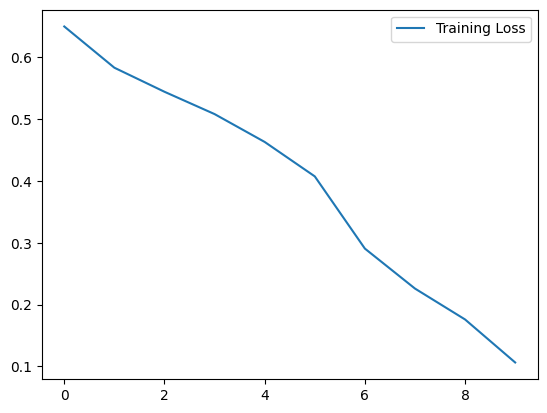

In [27]:
args = Args(name_of_experiment="mambafrz_20_conv_seed_25_experiment_same_seed_reference/training_data_redo_validation", context_window_size=30, number_of_samples=80000, re_size=1024, num_epochs=10, generate_training_data=False)
main(args)